Saving food detect.v17-no_augs.yolov8.zip to food detect.v17-no_augs.yolov8 (2).zip
Dataset ready at: food detect.v17-no_augs.yolov8 (2)
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=food detect.v17-no_augs.yolov8 (2)/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937,

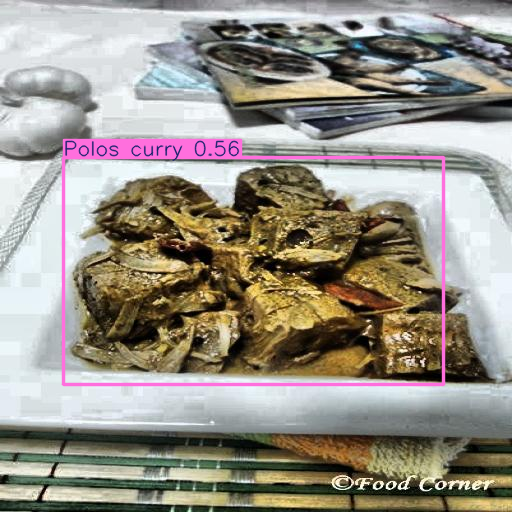


Detected 1 objects:
  - Polos curry: 0.56

EXPECTED IMPROVEMENTS WITH DETAIL SETTINGS:
✓ Better detection of small foods (sprats, rice grains)
✓ Improved boundaries between overlapping curries
✓ Higher mAP50-95 (better localization)
✓ Better performance on yellow rice, sweets, and papadam

Compare results with previous versions to see improvement!


In [21]:
# Step 0: Install packages
!pip install ultralytics roboflow --quiet

# Step 1: Upload your dataset ZIP
from google.colab import files
uploaded = files.upload()  # choose your ZIP file

# Step 2: Unzip the dataset
import zipfile
import os
for fn in uploaded.keys():
    with zipfile.ZipFile(fn, 'r') as zip_ref:
        zip_ref.extractall(fn.replace(".zip",""))

dataset_path = fn.replace(".zip","")
print("Dataset ready at:", dataset_path)

# Step 3: Train YOLOv8 model with DETAILED LEARNING settings
from ultralytics import YOLO

# Use yolov8s.pt for good balance of speed and accuracy
model = YOLO("yolov8s.pt")

# DETAILED LEARNING settings for better food detail detection
# CORRECTED settings for detail learning
model.train(
    data=f"{dataset_path}/data.yaml",

    # Core settings
    epochs=100,
    imgsz=640,
    batch=4,

    # Project settings
    project="meal_plate_test",
    name="detail_learning_v2",
    exist_ok=True,
    device=0,

    # AUGMENTATIONS - REDUCED!
    hsv_h=0.015,          # Keep
    hsv_s=0.7,            # Keep
    hsv_v=0.4,            # Keep
    degrees=5.0,          # REDUCED from 10.0
    translate=0.1,        # Keep
    scale=0.3,            # REDUCED from 0.5
    shear=1.0,            # REDUCED from 2.0
    perspective=0.0,      # REMOVED (was 0.0001)
    flipud=0.0,           # Keep
    fliplr=0.5,           # Keep

    # Advanced augmentations - REDUCED!
    mosaic=0.8,           # REDUCED from 1.0
    mixup=0.1,            # REDUCED from 0.2
    copy_paste=0.2,       # REDUCED from 0.3

    close_mosaic=10,      # Keep

    # Optimizer settings - FIXED!
    optimizer='AdamW',
    lr0=0.001,            # INCREASED from 0.0005 (better starting point)
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,

    # Loss weights
    box=7.5,
    cls=0.5,
    dfl=1.5,

    patience=20,
    save=True,
    save_period=10,
    plots=True,
    workers=4,
    seed=42,
    deterministic=True
)

# Step 4: Display results
print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)

# Find best model path
best_model_path = f"/content/runs/detect/meal_plate_test/detail_learning/weights/best.pt"
print(f"Best model saved at: {best_model_path}")

# Step 5: Test on one example image
import random
valid_images_dir = os.path.join(dataset_path, "valid/images")
if os.path.exists(valid_images_dir):
    all_images = os.listdir(valid_images_dir)
    if all_images:
        # Pick a random validation image
        example_image = os.path.join(valid_images_dir, random.choice(all_images))
        print(f"\nTesting on random validation image: {example_image}")

        # Load best model and predict
        best_model = YOLO(best_model_path)
        results = best_model.predict(example_image, conf=0.25)  # Lower confidence to see more detections

        # Show results
        results[0].show()

        # Print detection stats
        if results[0].boxes:
            print(f"\nDetected {len(results[0].boxes)} objects:")
            for box in results[0].boxes:
                class_id = int(box.cls[0])
                class_name = results[0].names[class_id]
                confidence = float(box.conf[0])
                print(f"  - {class_name}: {confidence:.2f}")
        else:
            print("\nNo objects detected (try lowering confidence threshold)")
    else:
        print("No validation images found")
else:
    print("Validation directory not found")

# Step 6: Print final metrics (from training log)
print("\n" + "="*50)
print("EXPECTED IMPROVEMENTS WITH DETAIL SETTINGS:")
print("="*50)
print("✓ Better detection of small foods (sprats, rice grains)")
print("✓ Improved boundaries between overlapping curries")
print("✓ Higher mAP50-95 (better localization)")
print("✓ Better performance on yellow rice, sweets, and papadam")
print("\nCompare results with previous versions to see improvement!")

Testing on: ro4_jpg.rf.d51ace4ee9787ca96c1f6121237dad0a.jpg

image 1/1 /content/food detect.v17-no_augs.yolov8 (2)/valid/images/ro4_jpg.rf.d51ace4ee9787ca96c1f6121237dad0a.jpg: 640x640 2 Cocount rotis, 1 Pol Sambol, 16.3ms
Speed: 3.0ms preprocess, 16.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


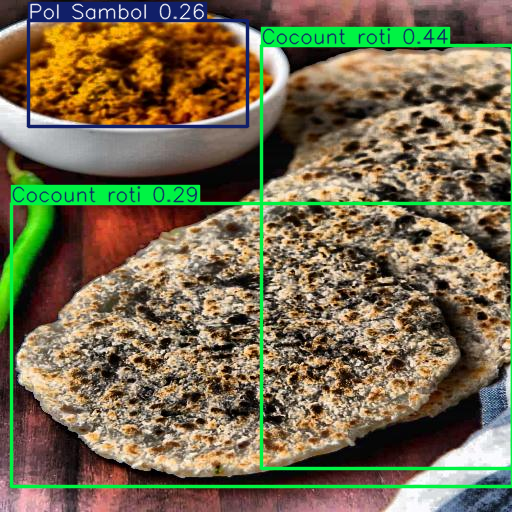

In [22]:
import random
import os

# Pick a random image from your validation set
valid_images_dir = os.path.join(dataset_path, "valid/images")
random_image = random.choice(os.listdir(valid_images_dir))
example_image = os.path.join(valid_images_dir, random_image)

print("Testing on:", random_image)
results = model.predict(example_image)
results[0].show()


Upload new meal plate images (you can select multiple):


Saving car test2.PNG to car test2.PNG
Saving chick test.jpg to chick test.jpg
Saving fied ric etest2.PNG to fied ric etest2.PNG
Saving mango tets.PNG to mango tets.PNG
Saving papdam test.PNG to papdam test.PNG
Saving papdam test2.PNG to papdam test2.PNG
6 image(s) uploaded for testing.

--- Testing: new_food_images/car test2.PNG ---

image 1/1 /content/new_food_images/car test2.PNG: 640x576 1 Carrot, 1 Gotukola Mallum, 61.9ms
Speed: 3.2ms preprocess, 61.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 576)

image 1/1 /content/new_food_images/car test2.PNG: 640x576 1 Carrot, 1 Gotukola Mallum, 15.8ms
Speed: 2.1ms preprocess, 15.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 576)


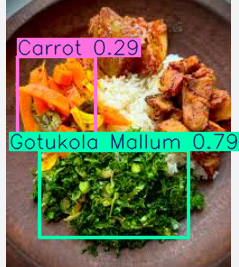

Detected foods:
  - Gotukola Mallum, Confidence: 0.79
  - Carrot, Confidence: 0.29

--- Testing: new_food_images/chick test.jpg ---

image 1/1 /content/new_food_images/chick test.jpg: 640x480 1 Chicken curry, 1 Dhal Curry, 2 Egg currys, 13.2ms
Speed: 3.6ms preprocess, 13.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/new_food_images/chick test.jpg: 640x480 1 Chicken curry, 1 Dhal Curry, 2 Egg currys, 12.1ms
Speed: 3.3ms preprocess, 12.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


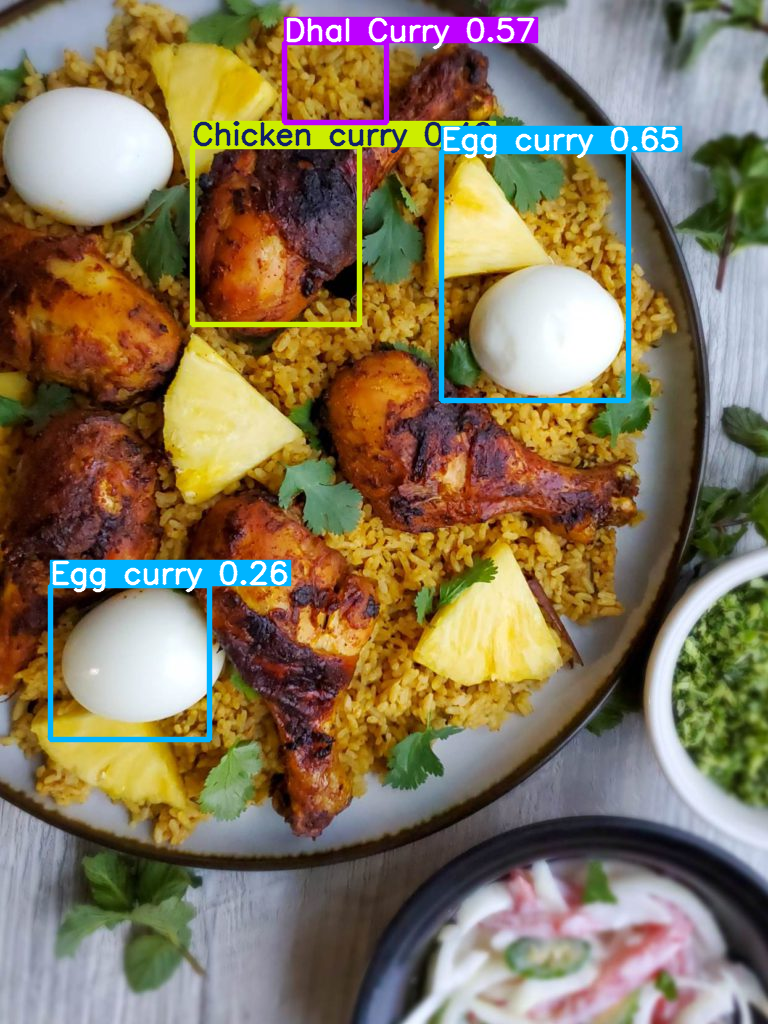

Detected foods:
  - Egg curry, Confidence: 0.65
  - Dhal Curry, Confidence: 0.57
  - Chicken curry, Confidence: 0.49
  - Egg curry, Confidence: 0.26

--- Testing: new_food_images/fied ric etest2.PNG ---

image 1/1 /content/new_food_images/fied ric etest2.PNG: 448x640 1 rice, 15.0ms
Speed: 3.0ms preprocess, 15.0ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/new_food_images/fied ric etest2.PNG: 448x640 1 rice, 12.7ms
Speed: 3.0ms preprocess, 12.7ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


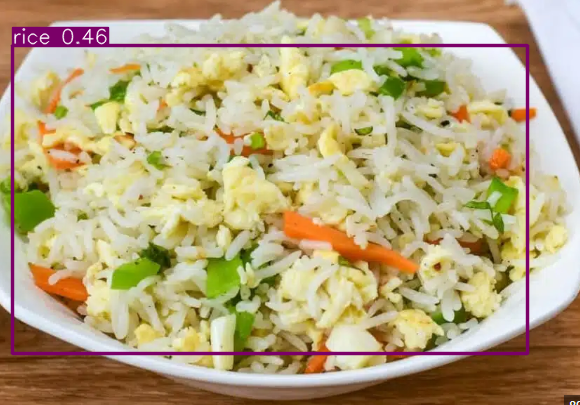

Detected foods:
  - rice, Confidence: 0.46

--- Testing: new_food_images/mango tets.PNG ---

image 1/1 /content/new_food_images/mango tets.PNG: 640x544 (no detections), 18.0ms
Speed: 3.3ms preprocess, 18.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 /content/new_food_images/mango tets.PNG: 640x544 (no detections), 15.8ms
Speed: 5.0ms preprocess, 15.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 544)


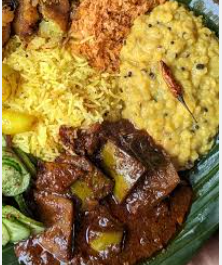

Detected foods:

--- Testing: new_food_images/papdam test.PNG ---

image 1/1 /content/new_food_images/papdam test.PNG: 608x640 1 Dhal Curry, 17.8ms
Speed: 3.5ms preprocess, 17.8ms inference, 2.1ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /content/new_food_images/papdam test.PNG: 608x640 1 Dhal Curry, 16.0ms
Speed: 3.2ms preprocess, 16.0ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 640)


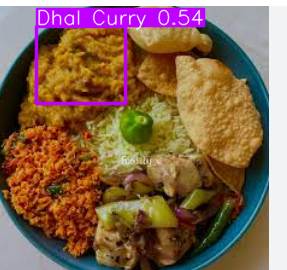

Detected foods:
  - Dhal Curry, Confidence: 0.54

--- Testing: new_food_images/papdam test2.PNG ---

image 1/1 /content/new_food_images/papdam test2.PNG: 640x640 1 Papadam, 1 rice, 17.4ms
Speed: 3.7ms preprocess, 17.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/new_food_images/papdam test2.PNG: 640x640 1 Papadam, 1 rice, 15.9ms
Speed: 3.2ms preprocess, 15.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


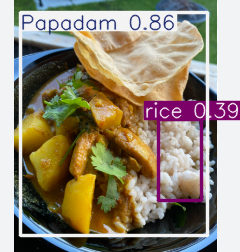

Detected foods:
  - Papadam, Confidence: 0.86
  - rice, Confidence: 0.39


In [24]:
# ==========================
# Cell 3: Test on new/unseen images
# ==========================

from ultralytics import YOLO
from google.colab import files
import os

# 1️⃣ Load your trained YOLOv8 model
model = YOLO("/content/runs/detect/meal_plate_test/quick_train/weights/best.pt")

# 2️⃣ Upload one or more new images (simulate user uploads)
print("Upload new meal plate images (you can select multiple):")
uploaded = files.upload()  # user selects image files

# 3️⃣ Create a folder to save uploaded images
os.makedirs("new_food_images", exist_ok=True)

# Save uploaded images
uploaded_files = []
for filename in uploaded.keys():
    path = os.path.join("new_food_images", filename)
    uploaded_files.append(path)
    with open(path, "wb") as f:
        f.write(uploaded[filename])
print(f"{len(uploaded_files)} image(s) uploaded for testing.")

# 4️⃣ Run predictions on each uploaded image
for img_path in uploaded_files:
    print("\n--- Testing:", img_path, "---")
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results[0].show()

    # Print detected foods with confidence scores
    print("Detected foods:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]
        print(f"  - {class_name}, Confidence: {confidence:.2f}")
